# 4 · Seed-ensemble: el modelo final

El VAE `recon_prob` era el mejor pero **cada semilla converge distinto** → varianza
alta. Solución: **seed-ensemble** — entrenar N VAEs con semillas distintas y **promediar
sus scores** (z-normalizados por miembro). El ruido idiosincrático se cancela.

In [63]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [64]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
soja  train: (6143, 72) | test anómalas: 251
maíz  train: (8082, 72) | test anómalas: 344


In [65]:
BEST = {
    "soja": dict(hidden_dims=(128, 64), latent_dim=16, beta=1.0),
    "maiz": dict(hidden_dims=(128, 64), latent_dim=24, beta=1.0),
}  # config ganadora de CADA cultivo (nb 3, sección 3.1) — no es la misma arquitectura
   # para los dos: soja prefiere latent_dim=16, maíz latent_dim=24 (ver nb 3)

## 4.1 · El seed-ensemble
`EnsembleDetector` toma una lista de detectores ya construidos, normaliza el score de cada
uno y los promedia. Cada miembro es un VAE con la config ganadora **de ese cultivo** (nb 3
— soja y maíz no comparten arquitectura). Armamos 10 con semillas 42..51 — el ensemble está
totalmente a la vista:

In [66]:
def make_ensemble(cultivo, base_seed):
    miembros = [VAEDetector(**BEST[cultivo], n_mc_samples=50, score_mode="recon_prob",
                            max_epochs=300, patience=30,
                            random_state=base_seed+i) for i in range(10)]   # 10 semillas
    return EnsembleDetector(miembros, normalize="zscore", combine="mean")

# ±std del ensemble = 5 réplicas con semillas base distintas (50 VAEs en total por cultivo; tarda).
# Guardamos la réplica base=42 para reusarla en los gráficos de más abajo.
datasets = {"soja": ds, "maiz": dsm}
filas_ens = {"soja": [], "maiz": []}
ens_repr = {}
for cultivo, dset in datasets.items():
    for base in [42, 52, 62, 72, 82]:
        ens = make_ensemble(cultivo, base).fit(dset.X_train)
        filas_ens[cultivo].append(lab.metrics(ens.score_samples(dset.X_test), dset.y_test))
        if base == 42: ens_repr[cultivo] = ens
    print(f"VAE seed-ensemble ×10 ({cultivo}) — media±std de 5 réplicas:")
    display(lab.mean_std(filas_ens[cultivo]))

VAE seed-ensemble ×10 (soja) — media±std de 5 réplicas:


pr_auc              0.617±0.017
roc_auc             0.756±0.016
prec_at_k           0.590±0.030
recall_at_contam    0.306±0.004
dtype: str

VAE seed-ensemble ×10 (maiz) — media±std de 5 réplicas:


pr_auc              0.518±0.012
roc_auc             0.664±0.022
prec_at_k           0.472±0.028
recall_at_contam    0.256±0.006
dtype: str

## 4.2 · La varianza se desploma y la media sube
Comparamos el ensemble contra un VAE single (una semilla) — mismo modelo base, por cultivo:

In [67]:
single = {}
for cultivo, dset in datasets.items():
    single[cultivo] = [lab.metrics(VAEDetector(**BEST[cultivo], n_mc_samples=50,
                  score_mode="recon_prob", max_epochs=300, patience=30, random_state=s)
                  .fit(dset.X_train).score_samples(dset.X_test), dset.y_test) for s in SEEDS]
    print(f"{cultivo} — VAE single     :", lab.mean_std(single[cultivo])["pr_auc"])
    print(f"{cultivo} — VAE seed-ens ×10:", lab.mean_std(filas_ens[cultivo])["pr_auc"])

soja — VAE single     : 0.598±0.041
soja — VAE seed-ens ×10: 0.617±0.017
maiz — VAE single     : 0.490±0.054
maiz — VAE seed-ens ×10: 0.518±0.012


Y contra **todos los baselines** del nb 1 (estadísticos y de modelos), no solo el VAE single:

--- soja ---


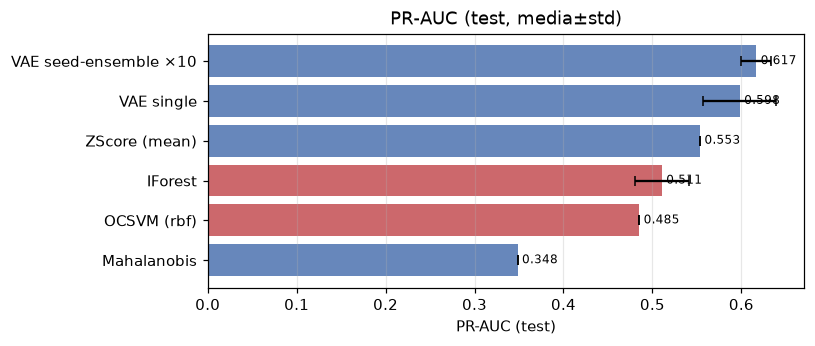

,pr_auc,roc_auc
VAE seed-ensemble ×10,0.617±0.017,0.756±0.016
VAE single,0.598±0.041,0.749±0.031
ZScore (mean),0.553±0.000,0.704±0.000
IForest,0.511±0.031,0.660±0.025
OCSVM (rbf),0.485±0.000,0.695±0.000
Mahalanobis,0.348±0.000,0.623±0.000


--- maíz ---


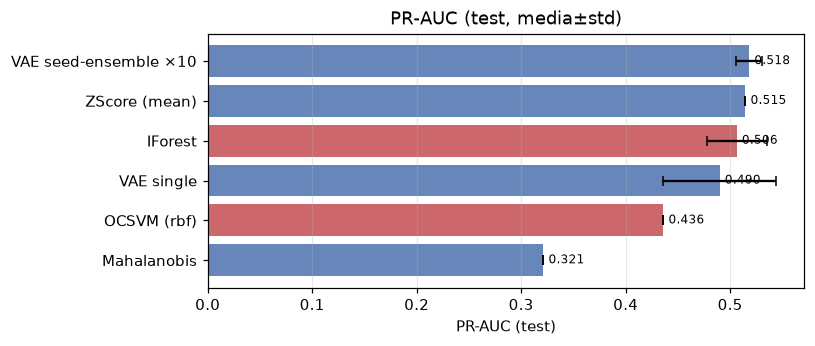

,pr_auc,roc_auc
VAE seed-ensemble ×10,0.518±0.012,0.664±0.022
ZScore (mean),0.515±0.000,0.645±0.000
IForest,0.506±0.029,0.649±0.025
VAE single,0.490±0.054,0.633±0.039
OCSVM (rbf),0.436±0.000,0.612±0.000
Mahalanobis,0.321±0.000,0.540±0.000


In [68]:
def comparar(dataset, single_c, filas_ens_c, nombre_cultivo):
    resumen_final = {
        "ZScore (mean)": [lab.metrics(ZScoreDetector(agg="mean").fit(dataset.X_train)
                                      .score_samples(dataset.X_test), dataset.y_test)],
        "Mahalanobis":   [lab.metrics(MahalanobisDetector(shrinkage=None).fit(dataset.X_train)
                                      .score_samples(dataset.X_test), dataset.y_test)],
        "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                    random_state=s).fit(dataset.X_train).score_samples(dataset.X_test), dataset.y_test)
                    for s in SEEDS],
        "OCSVM (rbf)": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                    .fit(dataset.X_train).score_samples(dataset.X_test), dataset.y_test)],
        "VAE single": single_c,
        "VAE seed-ensemble ×10": filas_ens_c,
    }
    print(f"--- {nombre_cultivo} ---")
    lab.plot_leaderboard(lab.leaderboard(resumen_final)); plt.show()
    display(lab.tabla(resumen_final))

comparar(ds, single["soja"], filas_ens["soja"], "soja")
comparar(dsm, single["maiz"], filas_ens["maiz"], "maíz")

En **soja**, el seed-ensemble trae una mejora clara: baja la varianza entre corridas y sube el PR-AUC medio respecto del VAE de una sola semilla. En **maíz**, en cambio, el ensemble no mejora el PR-AUC medio (un VAE individual llega parecido o algo más alto), pero sí **reduce la variabilidad** entre semillas.

En ambos casos el ensemble cumple su rol principal: **estabilizar el score** (menor desvío entre corridas), aunque la ganancia en PR-AUC dependa del cultivo.

El desvío cae fuerte **y la media sube**: el promedio de scores independientes gana en
media y en el peor caso — en ambos cultivos.

## 4.3 · El modelo final, en ambos cultivos


In [69]:
sc_soja = ens_repr["soja"].score_samples(ds.X_test)    
sc_maiz = ens_repr["maiz"].score_samples(dsm.X_test)   


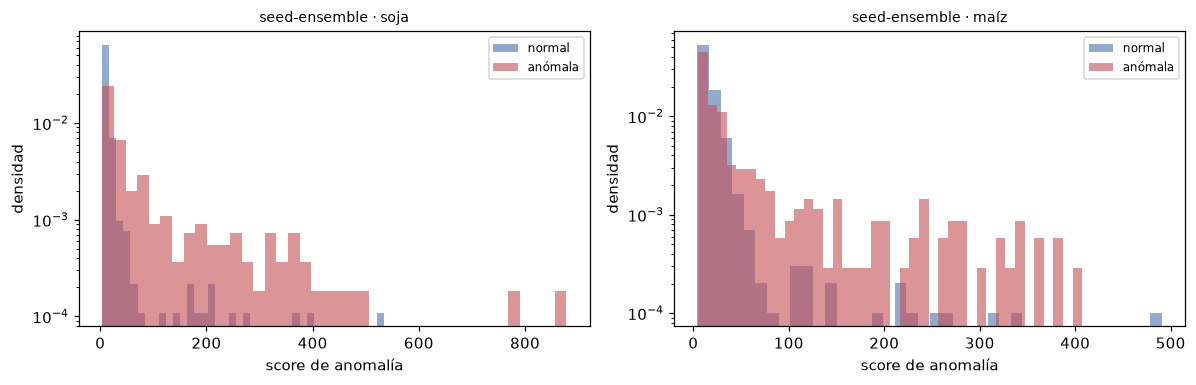

In [70]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
lab.plot_scores(sc_soja, ds.y_test, ax=axs[0], titulo="seed-ensemble · soja")
lab.plot_scores(sc_maiz, dsm.y_test, ax=axs[1], titulo="seed-ensemble · maíz")
plt.tight_layout(); plt.show()

se puede ver que la mayoría de las muestras, tanto normales como anómalas, se concentran en el mismo rango de scores bajos — hay un solapamiento fuerte entre las dos distribuciones ahí. Sin embargo, una cola de anomalías (rojo) se estira mucho más allá de donde llegan las normales, alcanzando valores de score varias veces más altos (hasta ~1400 en soja, ~700 en maíz) — ese es el subconjunto que el modelo sí logra separar con claridad. El resto de las anómalas, mezcladas con las normales en la zona de score bajo, son indistinguibles para el detector

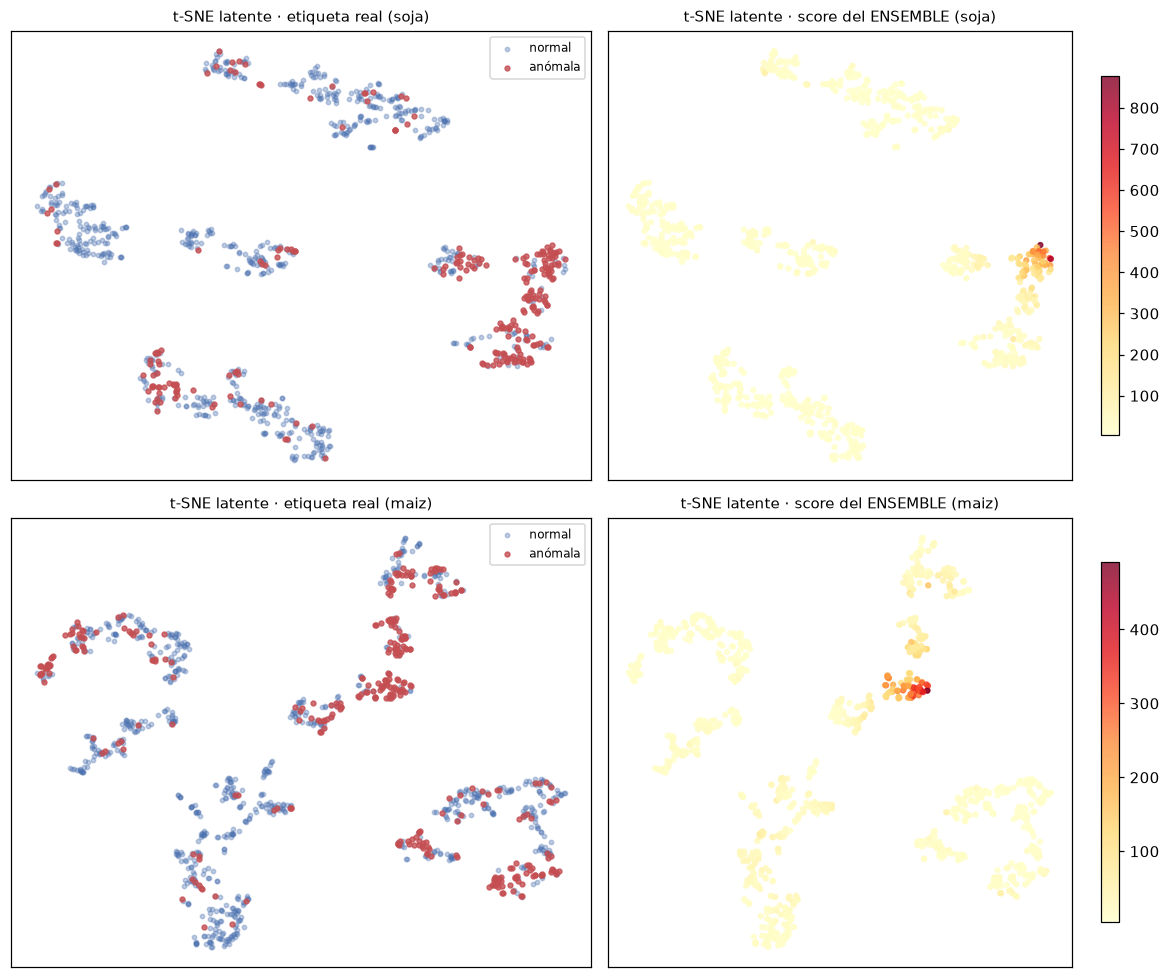

In [71]:
fig, axs = plt.subplots(2, 2, figsize=(11, 9))
sc_dict = {"soja": sc_soja, "maiz": sc_maiz}   # ya calculados en 4.3 (score del ensemble, réplica base=42)

for i, cultivo in enumerate(datasets):
    dset = datasets[cultivo]
    Zte_repr = ens_repr[cultivo].members[0].encode(dset.X_test)   # latente del miembro 0 (seed base=42)
    emb = lab.embed_2d(Zte_repr, method="tsne")
    lab.plot_embedding(emb, dset.y_test, kind="label", ax=axs[i, 0],
                       titulo=f"t-SNE latente · etiqueta real ({cultivo})")
    lab.plot_embedding(emb, sc_dict[cultivo], kind="score", ax=axs[i, 1],
                       titulo=f"t-SNE latente · score del ENSEMBLE ({cultivo})")
plt.tight_layout(); plt.show()

 en el t-SNE se puede ver una formación clara de clusters en el latente. Sin embargo, aunque hay uno que está mayormente formado por anomalías (rojo concentrado en una zona), el resto muestra un solapamiento fuerte entre normales y anómalas dentro de los mismos clusters. Esto va de la mano con el solapamiento que se ve en el histograma de scores: ahí también la mayoría de las anómalas (rojo) caen en el mismo rango de score bajo que las normales (azul), y solo una cola chica se estira a valores mucho más altos, sin que exista un corte limpio entre ambas distribuciones.

tanto en el espacio latente como en el score final, el modelo separa bien un subconjunto chico y extremo de anomalías (el cluster casi puro de un lado, la cola larga del otro), pero para el grueso de los casos anómalos no hay una frontera clara — ni geométrica ni de score — que los distinga de lo normal.



Se puede ver una gran diferencia entre cultivos. En soja, tanto el VAE single como el ensemble superan a todos los baselines, sin superar el 0.64. En maíz, en cambio, la historia es distinta: el VAE single presentó mucha variabilidad, quedando por debajo de los baselines, y el ensemble apenas logra superarlos. Esto puede deberse a que el rinde de maíz está menos ligado a las features climáticas presentes en los datos que el de soja, siendo así un problema de mayor complejidad.

Con esta información podemos interpretar que las anomalías no dependen en su totalidad de la firma climática que se presenta a lo largo del crecimiento del cultivo. También pueden estar afectadas por plagas, el estado del suelo o demás variables que actualmente no están presentes en el dataset.